In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from src.processing import Processing
import config
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [26]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.ORIG_FEATURES_FILE_PATH)
dataclass.read()
df = dataclass.preprocess()

# Step 2: Separate the features (X) and the target (y)
X = df.drop(columns=['group_name'])  # Features
y = df['group_name']  # Target

# Step 3: Split the data into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training+validation set into 70% training and 10% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) # Final split: 0.7 train, 0.1 val, 0.2 test

# Step 4: Calculate class weights based on the training set
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weights_dict)

# Step 5: Define the XGBoost model with class weights
model = xgb.XGBClassifier(random_state=42, scale_pos_weight=class_weights_dict[1])

# Step 6: Define the parameters for hyperparameter tuning (optional)
param_grid = {
    'n_estimators': [100, 200],  # Number of trees (boosting rounds)
    'max_depth': [3, 4, 5],  # Maximum depth of each tree
    'learning_rate': [0.01, 0.1, 0.2]  # Step size shrinkage
}

# Step 7: Use GridSearchCV for cross-validation (10 folds)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,  # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Print the process details
)

# Train the model on the original training set (no resampling)
grid_search.fit(X_train, y_train)

# You can now evaluate the performance on the validation and test sets.


Class Weights: {0: 2.891304347826087, 1: 0.6045454545454545}
Fitting 10 folds for each of 18 candidates, totalling 180 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [19]:

# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.ORIG_FEATURES_FILE_PATH)
dataclass.read()
df = dataclass.preprocess()

# Step 2: Separate the features (X) and the target (y)
X = df.drop(columns=['group_name'])  # Features
y = df['group_name']  # Target

# Step 3: Split the data into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training+validation set into 70% training and 10% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) # Final split: 0.7 train, 0.1 val, 0.2 test

# Step 4: Apply RandomUnderSampler to the training set
undersampler = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

# Verifying the new distribution after undersampling
print("Before undersampling:", y_train.value_counts())
print("After undersampling:", y_train_resampled.value_counts())

# Step 5: Define the XGBoost model
model = xgb.XGBClassifier(random_state=42)

# Step 6: Define the parameters for hyperparameter tuning (optional)
param_grid = {
    'n_estimators': [100, 200],  # Number of trees (boosting rounds)
    'max_depth': [3, 4, 5],  # Maximum depth of each tree
    'learning_rate': [0.01, 0.1, 0.2]  # Step size shrinkage
}

# Step 7: Use GridSearchCV for cross-validation (10 folds)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,  # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Print the process details
)

# Train the model on the resampled training set
grid_search.fit(X_train_resampled, y_train_resampled)

Before undersampling: group_name
1    220
0     46
Name: count, dtype: int64
After undersampling: group_name
0    46
1    46
Name: count, dtype: int64
Fitting 10 folds for each of 18 candidates, totalling 180 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [33]:
# Step 1: Load and preprocess the data
dataclass = Processing(source_path=config.ORIG_FEATURES_FILE_PATH)
dataclass.read()
df = dataclass.preprocess()

# Step 2: Separate the features (X) and the target (y)
X = df.drop(columns=['group_name'])  # Features
y = df['group_name']  # Target

# Step 3: Split the data into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split the training+validation set into 70% training and 10% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42) # Final split: 0.7 train, 0.1 val, 0.2 test

# Step 4: Apply SMOTE to the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Verifying the new distribution after SMOTE
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_resampled.value_counts())

# Step 5: Define the XGBoost model
model = xgb.XGBClassifier(random_state=42)

# Step 6: Define the parameters for hyperparameter tuning (optional)
param_grid = {
    'n_estimators': [100, 200],  # Number of trees (boosting rounds)
    'max_depth': [3, 4, 5],  # Maximum depth of each tree
    'learning_rate': [0.01, 0.1, 0.2]  # Step size shrinkage
}

# Step 7: Use GridSearchCV for cross-validation (10 folds)
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=10,  # 10-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,  # Use all available CPU cores
    verbose=1  # Print the process details
)

# Train the model on the resampled training set
grid_search.fit(X_train_resampled, y_train_resampled)

# You can now evaluate the performance on the validation and test sets.



Before SMOTE: group_name
1    178
0     35
Name: count, dtype: int64
After SMOTE: group_name
0    178
1    178
Name: count, dtype: int64
Fitting 10 folds for each of 18 candidates, totalling 180 fits


GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [35]:
# Print the best model and hyperparameters found
best_model = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_ * 100:.2f}%")

# Save the best model to a file
joblib.dump(best_model, 'best_xgboost_model.pkl')
print("Best model saved as 'best_xgboost_model.pkl'")

Best parameters found: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
Best cross-validation accuracy: 91.87%
Best model saved as 'best_xgboost_model.pkl'


Accuracy on the training set: 100.00%
F1 score on the training set: 100.00%
Accuracy on the validation set: 79.35%
F1 score on the validation set: 79.75%
Accuracy on the test set: 80.52%
F1 score on the test set: 82.47%
Classification report on the test set:

              precision    recall  f1-score   support

           0       0.23      0.38      0.29         8
           1       0.92      0.86      0.89        69

    accuracy                           0.81        77
   macro avg       0.58      0.62      0.59        77
weighted avg       0.85      0.81      0.82        77



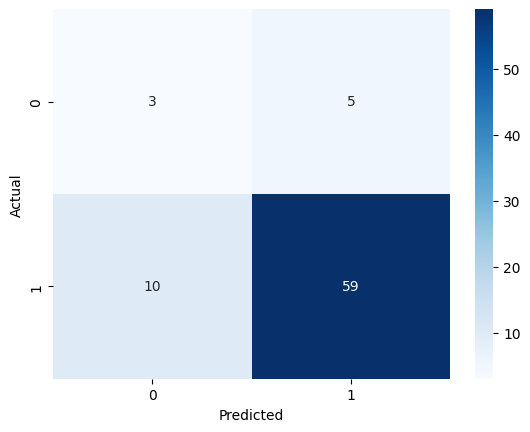

In [36]:
# Step 7: Evaluate the best model on the training set
y_train_pred = best_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
#train_roc_auc = roc_auc_score(y_train, best_model.predict_proba(X_train), multi_class='ovr', average='weighted')
print(f'Accuracy on the training set: {train_accuracy * 100:.2f}%')
print(f'F1 score on the training set: {train_f1 * 100:.2f}%')
#print(f'ROC AUC on the training set: {train_roc_auc * 100:.2f}%')

# Step 8: Evaluate the best model on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='weighted')
#val_roc_auc = roc_auc_score(y_val, best_model.predict_proba(X_val), multi_class='ovr', average='weighted')
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
print(f'F1 score on the validation set: {val_f1 * 100:.2f}%')
#print(f'ROC AUC on the validation set: {val_roc_auc * 100:.2f}%')

# Step 9: Evaluate the best model on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
#test_roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test), multi_class='ovr', average='weighted')
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
print(f'F1 score on the test set: {test_f1 * 100:.2f}%')
#print(f'ROC AUC on the test set: {test_roc_auc * 100:.2f}%')
print(f'Classification report on the test set:\n')
print(classification_report(y_test, y_test_pred))

# Step 10: Plot the confusion matrix
confusion_matrix = pd.crosstab(y_test, y_test_pred, rownames=['Actual'], colnames=['Predicted'])
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()


97


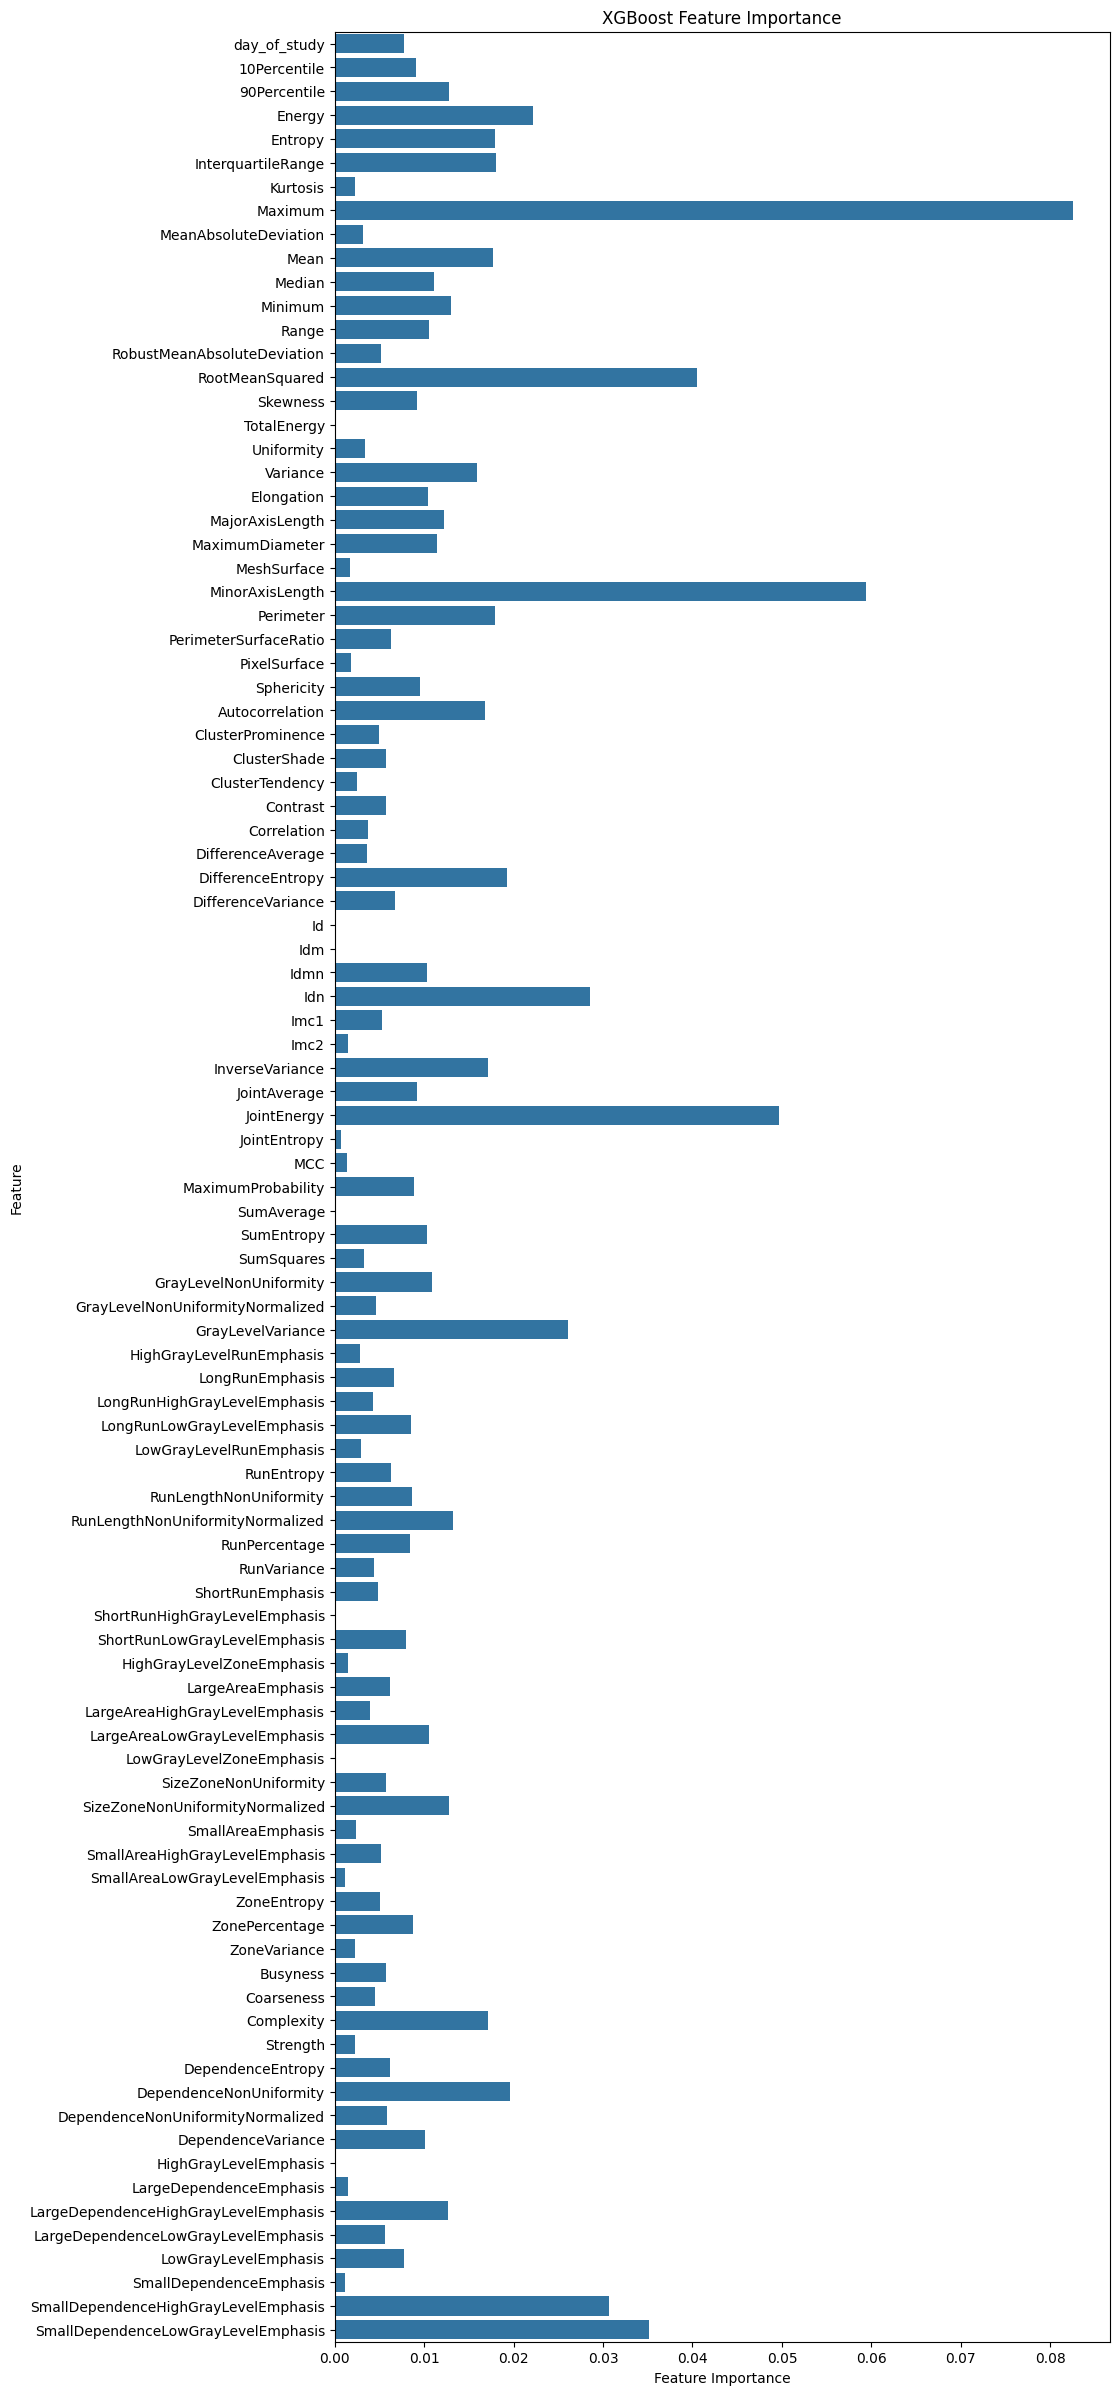

In [11]:
importances_best_model = best_model.feature_importances_

# Plot the feature importance
print(len(importances_best_model))

plt.figure(figsize=(10, 30))
sns.barplot(x=importances_best_model, y=X.columns)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance')
plt.show()

In [12]:
# Number of top features to select (e.g., the 10 most important)
num_top_features = 10

# Select the N most important features based on feature importance from XGBoost
important_features_indices = np.argsort(importances_best_model)[-num_top_features:]  # The most important at the end
X_train_selected = X_train.iloc[:, important_features_indices]
X_val_selected = X_val.iloc[:, important_features_indices]
X_test_selected = X_test.iloc[:, important_features_indices]

# Display the selected features' names
print(X_train.columns[important_features_indices])

# Train the model using only the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.01, random_state=42)  # You can reuse the best parameters
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
print(f'Accuracy on the validation set: {accuracy_score(y_val, y_val_pred) * 100:.2f}%')
class_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set (selected features):\n{class_report}')

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)
print(f'Accuracy on the test set: {accuracy_score(y_test, y_test_pred) * 100:.2f}%')
class_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set (selected features):\n{class_report}')


Index(['DependenceNonUniformity', 'Energy', 'GrayLevelVariance', 'Idn',
       'SmallDependenceHighGrayLevelEmphasis',
       'SmallDependenceLowGrayLevelEmphasis', 'RootMeanSquared', 'JointEnergy',
       'MinorAxisLength', 'Maximum'],
      dtype='object')
Accuracy on the validation set: 71.79%
Classification report on the validation set (selected features):
              precision    recall  f1-score   support

           0       0.67      0.17      0.27        12
           1       0.72      0.96      0.83        27

    accuracy                           0.72        39
   macro avg       0.69      0.56      0.55        39
weighted avg       0.71      0.72      0.65        39

Accuracy on the test set: 92.21%
Classification report on the test set (selected features):
              precision    recall  f1-score   support

           0       0.75      0.38      0.50         8
           1       0.93      0.99      0.96        69

    accuracy                           0.92        77


Accuracy on the validation set (selected features): 74.36%
Accuracy on the test set (selected features): 87.01%
10


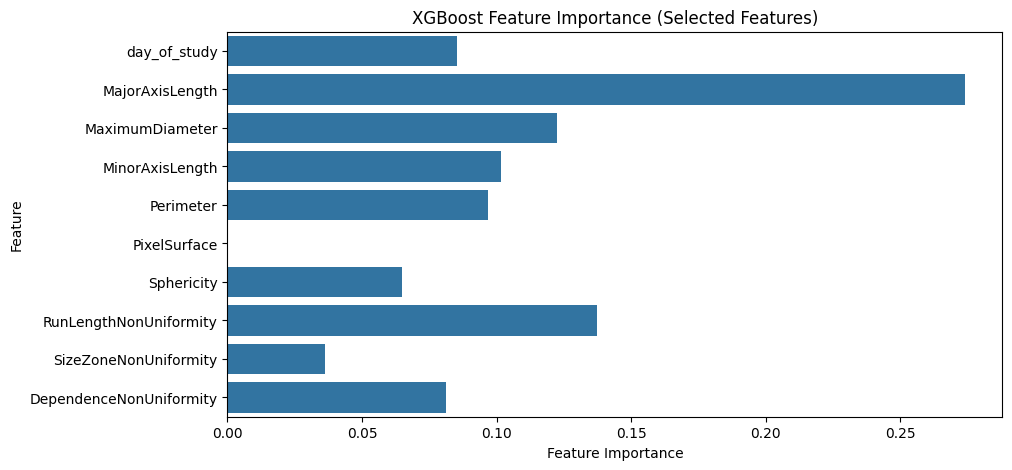

In [13]:
# Apply feature selection

# Select the top 10 features
selector = SelectKBest(chi2, k=10)
X_train_selected = selector.fit_transform(X_train, y_train)
X_val_selected = selector.transform(X_val)
X_test_selected = selector.transform(X_test)

# Train a new XGBoost model on the selected features
model_selected = xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.01, random_state=42 )# Best parameters found: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}
model_selected.fit(X_train_selected, y_train)

# Evaluate the model on the validation set
y_val_pred = model_selected.predict(X_val_selected)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set (selected features): {val_accuracy * 100:.2f}%')

# Evaluate the model on the test set
y_test_pred = model_selected.predict(X_test_selected)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set (selected features): {test_accuracy * 100:.2f}%')

# Plot the feature importance
print(len(model_selected.feature_importances_))

plt.figure(figsize=(10, 5))
sns.barplot(x=model_selected.feature_importances_, y=X.columns[selector.get_support()])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('XGBoost Feature Importance (Selected Features)')
plt.show()

In [14]:
# Train a SVM model
svm_model = svm.SVC()

# Define the parameters for the Grid Search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly'],  # Types of kernel
    'gamma': ['scale', 'auto']  # For non-linear kernels
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=svm_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

Best parameters found: {'C': 100, 'gamma': 'scale', 'kernel': 'poly'}
Accuracy on the validation set: 69.23%
Classification report on the validation set:
              precision    recall  f1-score   support

           0       0.50      0.08      0.14        12
           1       0.70      0.96      0.81        27

    accuracy                           0.69        39
   macro avg       0.60      0.52      0.48        39
weighted avg       0.64      0.69      0.61        39

Accuracy on the test set: 89.61%
Classification report on the test set:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         8
           1       0.90      1.00      0.95        69

    accuracy                           0.90        77
   macro avg       0.45      0.50      0.47        77
weighted avg       0.80      0.90      0.85        77



c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\xavie\miniconda3\envs\tfm\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [15]:
# Define the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameters for the Grid Search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']  # The number of features to consider when looking for the best split
}

# Configure the Grid Search with cross-validation
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, 
                           scoring='accuracy', cv=5, n_jobs=-1)

# Fit the Grid Search to the training data
grid_search.fit(X_train, y_train)

# Get the best parameters and the best model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f'Best parameters found: {best_params}')

# Predict on the validation set
y_val_pred = best_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f'Accuracy on the validation set: {val_accuracy * 100:.2f}%')
c_report = classification_report(y_val, y_val_pred)
print(f'Classification report on the validation set:\n{c_report}')

# Predict on the test set
y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Accuracy on the test set: {test_accuracy * 100:.2f}%')
c_report = classification_report(y_test, y_test_pred)
print(f'Classification report on the test set:\n{c_report}')

KeyboardInterrupt: 